<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/day_3_heart_disease_prediction_svm_k_near_neigho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 - Notebook 1: Heart Disease Prediction
## Support Vector Machines & K-Nearest Neighbours

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 3 | July 15, 2025 | 9:00 AM - 12:00 PM**

---

## Objective
Predict whether a patient has heart disease using two algorithms from opposite ends of the spectrum:
SVM (a margin-maximising geometric classifier) and KNN (a pure distance-based lazy learner).

| Step | What you do | What you learn |
|------|-------------|----------------|
| 1 | Load and explore data | Clinical features, no missing values |
| 2 | Preprocess | Scaling is critical for both SVM and KNN |
| 3 | Train SVM (linear + RBF) | Margin, C parameter, kernel trick |
| 4 | Tune C and gamma | GridSearchCV on SVM |
| 5 | Train KNN | k selection, distance metrics |
| 6 | k experiment | Plot val accuracy vs k |
| 7 | Compare SVM vs KNN | ROC curves, metrics table |
| 8 | SVM: visualise support vectors | Which patients define the boundary? |

**Dataset:** Heart Disease UCI  
**Kaggle path:** `/kaggle/input/heart-disease-uci/heart.csv`  
**Dataset URL:** https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data  
**Task:** Binary classification - predict `target` (1 = heart disease, 0 = no disease)  
**Why this dataset for SVM/KNN?** 13 numeric/ordinal features, no missing values, 303 rows.
Small and clean = ideal for understanding what SVM and KNN are actually doing.

---
> **Key concept:** Both SVM and KNN are VERY sensitive to feature scaling.
> A feature with range 0-300 will dominate over a feature with range 0-1 unless you scale first.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import psutil

process = psutil.Process(os.getpid())
warnings.filterwarnings('ignore')

from sklearn.svm               import SVC
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.preprocessing     import StandardScaler
from sklearn.model_selection   import (train_test_split, GridSearchCV,
                                        cross_val_score, StratifiedKFold)
from sklearn.metrics           import (accuracy_score, f1_score, roc_auc_score,
                                        classification_report, confusion_matrix,
                                        ConfusionMatrixDisplay, roc_curve)
from sklearn.pipeline          import Pipeline

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


In [ ]:
# Load data
DATASET_PATH = '/kaggle/input/datasets/johnsmith88/heart-disease-dataset'
# DATASET_PATH = '.'  # uncomment for local run

df = pd.read_csv(f'{DATASET_PATH}/heart.csv')

print(f'Shape: {df.shape}')
print(f'Heart disease rate: {df["target"].mean()*100:.1f}%')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nData types:\n{df.dtypes}')
display(df.head())

Shape: (1025, 14)
Heart disease rate: 51.3%

Missing values: 0

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Section 2 - EDA

The UCI Heart Disease dataset has 13 features:

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1=male, 0=female) | Binary |
| `cp` | Chest pain type (0-3) | Ordinal |
| `trestbps` | Resting blood pressure (mmHg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl | Binary |
| `restecg` | Resting ECG results (0-2) | Ordinal |
| `thalach` | Maximum heart rate achieved | Numeric |
| `exang` | Exercise-induced angina (1=yes) | Binary |
| `oldpeak` | ST depression induced by exercise | Numeric |
| `slope` | Slope of peak exercise ST (0-2) | Ordinal |
| `ca` | Number of major vessels (0-3) | Ordinal |
| `thal` | Thal: 0=normal, 1=fixed, 2=reversible | Ordinal |

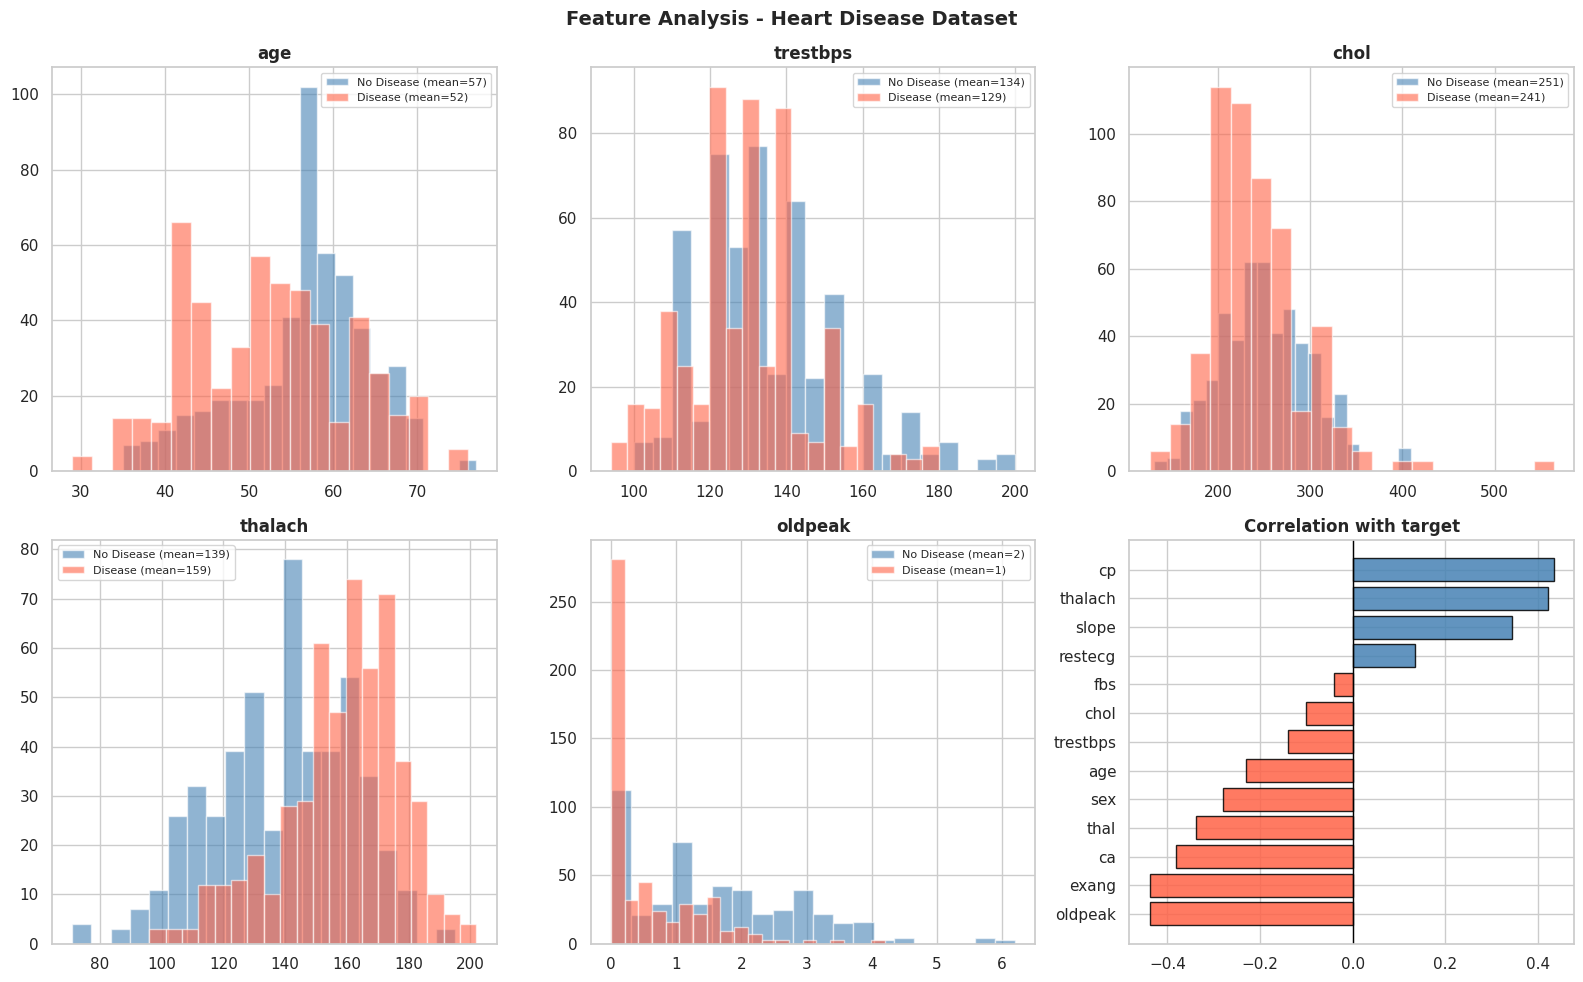

In [ ]:
# Feature distributions by class
numeric_feats = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_feats):
    no_disease = df[df['target']==0][col]
    disease    = df[df['target']==1][col]
    axes[i].hist(no_disease, bins=20, color='steelblue', alpha=0.6,
                 label=f'No Disease (mean={no_disease.mean():.0f})', edgecolor='white')
    axes[i].hist(disease,    bins=20, color='tomato',    alpha=0.6,
                 label=f'Disease (mean={disease.mean():.0f})', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)

# Correlation heatmap in last panel
corr = df.corr()['target'].drop('target').sort_values()
colors = ['tomato' if v < 0 else 'steelblue' for v in corr.values]
axes[5].barh(corr.index, corr.values, color=colors, edgecolor='black', alpha=0.85)
axes[5].axvline(0, color='black', linewidth=1)
axes[5].set_title('Correlation with target', fontweight='bold')

plt.suptitle('Feature Analysis - Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 3 - Preprocessing

**Why scaling is mandatory for SVM and KNN:**

- SVM maximises the margin between classes. The margin width depends on the scale of features.
  If `chol` ranges from 100-600 and `fbs` is 0 or 1, cholesterol will dominate the margin calculation.
- KNN computes distances between points. Unscaled features with large ranges completely
  overwhelm features with small ranges in the distance calculation.

After scaling: every feature has mean=0 and std=1. All features contribute equally.

In [ ]:
TARGET   = 'target'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Scale - ALWAYS fit on train only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Disease rate - Train: {y_train.mean()*100:.1f}%  Val: {y_val.mean()*100:.1f}%')
print(f'\nAfter scaling - feature means (should be ~0): {X_train_s.mean(axis=0).round(2)}')
print(f'After scaling - feature stds  (should be ~1): {X_train_s.std(axis=0).round(2)}')

Train: 656  Val: 164  Test: 205
Disease rate - Train: 51.4%  Val: 51.2%

After scaling - feature means (should be ~0): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0. -0.  0. -0.]
After scaling - feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Section 4 - Support Vector Machine

**The idea:** Find the hyperplane that maximises the gap (margin) between the two classes.
The points on the margin boundary are called **support vectors** -- they define the decision boundary.

**C parameter:** Controls the trade-off between margin width and training errors.
- Large C: strict, narrow margin, penalises every misclassification (may overfit)
- Small C: tolerant, wide margin, allows some misclassifications (better generalisation)

**Kernel:** Maps data to a higher-dimensional space where a linear boundary works.
- `linear`: straight hyperplane - fast, good for text
- `rbf`: Gaussian kernel - general purpose, handles non-linear patterns

In [ ]:
training_start = time.time()

svm.fit(X_train_s, y_train)

training_end = time.time()
svm_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

preds = svm.predict(X_val_s)
probs = svm.predict_proba(X_val_s)[:,1]

prediction_end = time.time()
svm_prediction_time = prediction_end - prediction_start

import pickle

with open("svm_model.pkl","wb") as f:
    pickle.dump(svm,f)

svm_model_size = os.path.getsize("svm_model.pkl")/(1024**2)

In [ ]:
training_start = time.time()

gs.fit(X_train_s,y_train)

training_end = time.time()
best_svm_training_time = training_end-training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss/(1024**2)

prediction_start = time.time()

best_svm=gs.best_estimator_

preds_best=best_svm.predict(X_val_s)
probs_best=best_svm.predict_proba(X_val_s)[:,1]

prediction_end=time.time()

best_svm_prediction_time=prediction_end-prediction_start

import pickle

with open("best_svm.pkl","wb") as f:
    pickle.dump(best_svm,f)

best_svm_model_size=os.path.getsize("best_svm.pkl")/(1024**2)

In [ ]:
# Tune C and gamma for RBF kernel using GridSearchCV
param_grid = {
    'C'    : [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 0.001, 0.01, 0.1, 1]
}

gs = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
gs.fit(X_train_s, y_train)

print(f'Best params: {gs.best_params_}')
print(f'Best CV AUC: {gs.best_score_:.4f}')

# Evaluate best model on validation set
best_svm   = gs.best_estimator_
preds_best = best_svm.predict(X_val_s)
probs_best = best_svm.predict_proba(X_val_s)[:,1]
print(f'Val AUC (tuned SVM): {roc_auc_score(y_val, probs_best):.4f}')
print(f'Val F1  (tuned SVM): {f1_score(y_val, preds_best):.4f}')

results['SVM (tuned RBF)'] = {
    'model': best_svm, 'preds': preds_best, 'probs': probs_best,
    'acc': accuracy_score(y_val, preds_best),
    'f1': f1_score(y_val, preds_best),
    'auc': roc_auc_score(y_val, probs_best)
}

Best params: {'C': 10, 'gamma': 1}
Best CV AUC: 0.9904
Val AUC (tuned SVM): 1.0000
Val F1  (tuned SVM): 0.9825


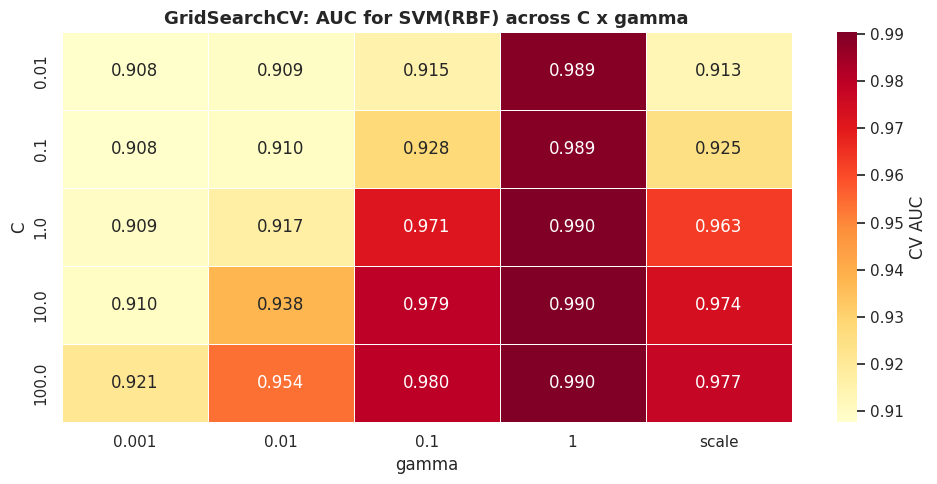

Insight: C and gamma interact strongly.
High C + high gamma = complex, potentially overfit boundary.
Low C + low gamma = smooth, potentially underfit boundary.


In [ ]:
# Heatmap: GridSearchCV results - AUC for every C x gamma combo
import pandas as pd
cv_results = pd.DataFrame(gs.cv_results_)
pivot = cv_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CV AUC'})
ax.set_title('GridSearchCV: AUC for SVM(RBF) across C x gamma',
             fontsize=13, fontweight='bold')
ax.set_xlabel('gamma'); ax.set_ylabel('C')
plt.tight_layout(); plt.show()

print('Insight: C and gamma interact strongly.')
print('High C + high gamma = complex, potentially overfit boundary.')
print('Low C + low gamma = smooth, potentially underfit boundary.')

## Section 5 - K-Nearest Neighbours

**The idea:** No training phase. To predict a new patient, find the k most similar patients
in the training set (by distance) and take a majority vote on their diagnoses.

**Key choices:**
- **k**: Low k = complex, noisy boundary. High k = smooth but may miss patterns.
  Find the best k by plotting validation accuracy vs k.
- **Distance metric**: Euclidean (default), Manhattan (robust to outliers), Cosine (text).
- **Always scale**: Distance is completely dominated by large-range features without scaling.

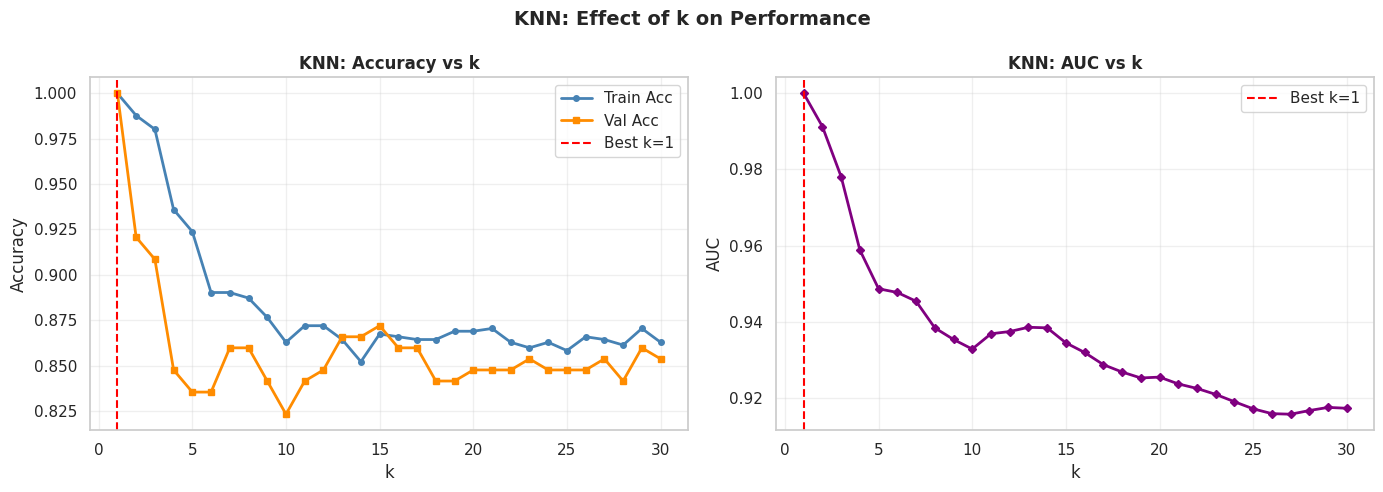

Best k by Accuracy: 1  (val acc=1.0000)
Best k by AUC     : 1  (val AUC=1.0000)
Rule-of-thumb k = sqrt(n_train) = 25


In [ ]:
# k experiment: accuracy and AUC vs k
k_range  = range(1, 31)
val_accs = []
val_aucs = []
tr_accs  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_s, y_train)
    tr_accs.append(knn.score(X_train_s, y_train))
    val_accs.append(knn.score(X_val_s, y_val))
    val_aucs.append(roc_auc_score(y_val, knn.predict_proba(X_val_s)[:,1]))

best_k_acc = list(k_range)[np.argmax(val_accs)]
best_k_auc = list(k_range)[np.argmax(val_aucs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, tr_accs,  'steelblue', linewidth=2, marker='o', markersize=4, label='Train Acc')
axes[0].plot(k_range, val_accs, 'darkorange', linewidth=2, marker='s', markersize=4, label='Val Acc')
axes[0].axvline(best_k_acc, color='red', linestyle='--', label=f'Best k={best_k_acc}')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('KNN: Accuracy vs k', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, val_aucs, 'purple', linewidth=2, marker='D', markersize=4)
axes[1].axvline(best_k_auc, color='red', linestyle='--', label=f'Best k={best_k_auc}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('AUC')
axes[1].set_title('KNN: AUC vs k', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('KNN: Effect of k on Performance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Best k by Accuracy: {best_k_acc}  (val acc={max(val_accs):.4f})')
print(f'Best k by AUC     : {best_k_auc}  (val AUC={max(val_aucs):.4f})')
print(f'Rule-of-thumb k = sqrt(n_train) = {int(np.sqrt(len(X_train)))}')

In [ ]:
training_start=time.time()

knn.fit(X_train_s,y_train)

training_end=time.time()
knn_training_time=training_end-training_start

cpu_after=psutil.cpu_percent(interval=1)
memory_after=process.memory_info().rss/(1024**2)

prediction_start=time.time()

preds=knn.predict(X_val_s)
probs=knn.predict_proba(X_val_s)[:,1]

prediction_end=time.time()

knn_prediction_time=prediction_end-prediction_start

import pickle

with open("knn.pkl","wb") as f:
    pickle.dump(knn,f)

knn_model_size=os.path.getsize("knn.pkl")/(1024**2)

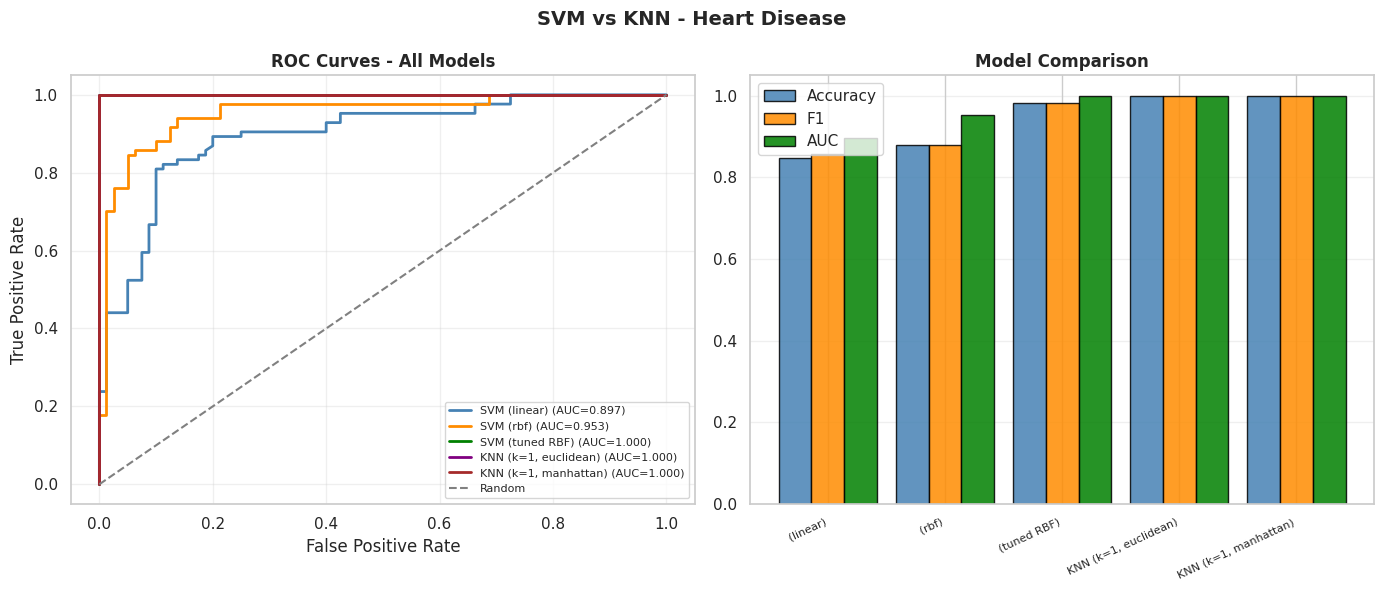

In [ ]:
# Final comparison: ROC curves + confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['steelblue', 'darkorange', 'green', 'purple', 'brown']
for (name, m), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, m['probs'])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} (AUC={m['auc']:.3f})")
axes[0].plot([0,1],[0,1],'gray',linestyle='--',linewidth=1.5,label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves - All Models', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Bar chart
model_names = list(results.keys())
accs = [results[n]['acc'] for n in model_names]
f1s  = [results[n]['f1']  for n in model_names]
aucs = [results[n]['auc'] for n in model_names]
x = np.arange(len(model_names))
w = 0.28
axes[1].bar(x-w, accs, w, label='Accuracy', color='steelblue',  alpha=0.85, edgecolor='black')
axes[1].bar(x,   f1s,  w, label='F1',       color='darkorange', alpha=0.85, edgecolor='black')
axes[1].bar(x+w, aucs, w, label='AUC',      color='green',      alpha=0.85, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace('SVM','').replace('KNN','KNN') for n in model_names],
                         rotation=25, ha='right', fontsize=8)
axes[1].set_title('Model Comparison', fontweight='bold')
axes[1].legend(); axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('SVM vs KNN - Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Scaling effect demonstration
print('=== EFFECT OF FEATURE SCALING ON KNN ===')
print()

knn_unscaled = KNeighborsClassifier(n_neighbors=best_k_auc)
knn_unscaled.fit(X_train, y_train)  # NO scaling
auc_unscaled = roc_auc_score(y_val, knn_unscaled.predict_proba(X_val)[:,1])

knn_scaled = KNeighborsClassifier(n_neighbors=best_k_auc)
knn_scaled.fit(X_train_s, y_train)  # WITH scaling
auc_scaled = roc_auc_score(y_val, knn_scaled.predict_proba(X_val_s)[:,1])

print(f'KNN AUC WITHOUT scaling: {auc_unscaled:.4f}')
print(f'KNN AUC WITH scaling   : {auc_scaled:.4f}')
print(f'Improvement from scaling: +{auc_scaled - auc_unscaled:.4f}')
print()
print('Without scaling, chol (100-600) and trestbps (90-200) dominate')
print('distance calculations and overwhelm binary features like fbs (0/1).')

=== EFFECT OF FEATURE SCALING ON KNN ===

KNN AUC WITHOUT scaling: 0.9574
KNN AUC WITH scaling   : 1.0000
Improvement from scaling: +0.0426

Without scaling, chol (100-600) and trestbps (90-200) dominate
distance calculations and overwhelm binary features like fbs (0/1).


In [ ]:
# Final results summary
print('=' * 60)
print('  DAY 3 NOTEBOOK 1 - FINAL RESULTS')
print('  Dataset: Heart Disease UCI (303 patients, 13 features)')
print('=' * 60)
best_name = max(results, key=lambda n: results[n]['auc'])
best_m    = results[best_name]
print(f"\n  Best model: {best_name}")
print(f'  Val Accuracy: {best_m["acc"]:.4f}')
print(f'  Val F1 Score: {best_m["f1"]:.4f}')
print(f'  Val AUC-ROC : {best_m["auc"]:.4f}')
print()
print(classification_report(y_val, best_m['preds'],
      target_names=['No Disease', 'Disease']))
print('Key lessons:')
print('  1. Always scale before SVM and KNN')
print('  2. SVM: tune C and gamma jointly with GridSearchCV')
print('  3. KNN: find best k by plotting val accuracy vs k (not just rule-of-thumb)')
print('  4. RBF kernel SVM handles non-linear patterns that linear kernel cannot')
print('  5. Support vectors are the only training points that define the boundary')

  DAY 3 NOTEBOOK 1 - FINAL RESULTS
  Dataset: Heart Disease UCI (303 patients, 13 features)

  Best model: SVM (tuned RBF)
  Val Accuracy: 0.9817
  Val F1 Score: 0.9825
  Val AUC-ROC : 1.0000

              precision    recall  f1-score   support

  No Disease       1.00      0.96      0.98        80
     Disease       0.97      1.00      0.98        84

    accuracy                           0.98       164
   macro avg       0.98      0.98      0.98       164
weighted avg       0.98      0.98      0.98       164

Key lessons:
  1. Always scale before SVM and KNN
  2. SVM: tune C and gamma jointly with GridSearchCV
  3. KNN: find best k by plotting val accuracy vs k (not just rule-of-thumb)
  4. RBF kernel SVM handles non-linear patterns that linear kernel cannot
  5. Support vectors are the only training points that define the boundary


In [ ]:
print("="*80)
print("FINAL PERFORMANCE SUMMARY")
print("="*80)

print("\n----- SVM -----")
print(f"Training Time   : {svm_training_time:.4f} sec")
print(f"Prediction Time : {svm_prediction_time:.6f} sec")
print(f"Model Size      : {svm_model_size:.6f} MB")

print("\n----- Tuned SVM -----")
print(f"Training Time   : {best_svm_training_time:.4f} sec")
print(f"Prediction Time : {best_svm_prediction_time:.6f} sec")
print(f"Model Size      : {best_svm_model_size:.6f} MB")

print("\n----- KNN -----")
print(f"Training Time   : {knn_training_time:.4f} sec")
print(f"Prediction Time : {knn_prediction_time:.6f} sec")
print(f"Model Size      : {knn_model_size:.6f} MB")

print("\n----- System -----")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")

print("="*80)

FINAL PERFORMANCE SUMMARY

----- SVM -----
Training Time   : 0.0599 sec
Prediction Time : 0.006958 sec
Model Size      : 0.033831 MB

----- Tuned SVM -----
Training Time   : 3.0902 sec
Prediction Time : 0.007628 sec
Model Size      : 0.035447 MB

----- KNN -----
Training Time   : 0.0038 sec
Prediction Time : 0.004676 sec
Model Size      : 0.083268 MB

----- System -----
CPU Usage       : 0.30%
Memory Usage    : 289.64 MB
